In [2]:
conda install torch

ModuleNotFoundError: No module named 'pexpect'

In [2]:
import torch 
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce GTX 1080 Ti


In [6]:
from netCDF4 import Dataset
import numpy as np
import pandas as pd 
# from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import seaborn as sns 
# from scipy.signal import savgol_filter

ImportError: Unable to import required dependencies:
pytz: No module named 'pytz'

In [2]:
training_data_path1 = r'new_dAtA/till xl.nc'
training_data_path2 = r'new_dAtA/after_xl.nc'
training_data_path3 = r'new_dAtA/tla_taux_tauy.nc'

In [4]:
# ds_depth_2022 = Dataset("dAtA/Sea_surface/gebco_2022_n40.5_s38.5_w-11.0_e-8.5.nc")
# all_ds = Dataset("/Users/hritik/Documents/Project /Wave-Prediction/dAtA/cmems_mod_ibi_wav_anfc_0.027deg_PT1H-i_multi-vars_11.00W-8.53W_38.50N-40.97N_2022-12-01-2025-01-01.nc")
# import xarray as xr

training_data_path1 = r'new_dAtA/till xl.nc'
training_data_path2 = r'new_dAtA/after_xl.nc'
training_data_path3 = r'new_dAtA/tla_taux_tauy.nc'

all_ds =  Dataset(training_data_path1)
all_ds1 =  Dataset(training_data_path2)
mini_ds =  Dataset(training_data_path3)

# ds1 = xr.open_dataset(training_data_path1, engine="netcdf4")
# ds2 = xr.open_dataset(training_data_path2, engine="netcdf4")
# merged_dataset = xr.merge([ds1, ds2], combine_attrs='drop')
# print(merged_dataset)

In [6]:
mini_ds["time"][:]

masked_array(data=[613620., 613621., 613622., ..., 648634., 648635.,
                   648636.],
             mask=False,
       fill_value=np.float64(1e+20),
            dtype=float32)

In [10]:
mini_ds["TLA"][0,:,:].data

array([[    99.,     99.,     99., ..., -32767., -32767., -32767.],
       [    99.,     99.,     99., ..., -32767., -32767., -32767.],
       [    99.,     99.,     99., ..., -32767., -32767., -32767.],
       ...,
       [    94.,     94.,     94., ...,     83.,     84.,     84.],
       [    94.,     94.,     94., ...,     83.,     84.,     84.],
       [    94.,     94.,     94., ...,     83.,     84.,     84.]],
      shape=(162, 162))

In [10]:
all_ds1.variables.keys()

dict_keys(['VPED', 'VSDX', 'VSDY', 'VTM01_SW1', 'VTM01_SW2', 'VTM01_WW', 'VTM02', 'VTM10', 'VTPK', 'latitude', 'longitude', 'time'])

In [6]:
# copernicusmarine subset -i cmems_mod_ibi_wav_anfc_0.027deg_PT1H-i -t 2022-12-01 -T 2025-01-01 -y 38.5 -Y 41.0 -x -11.0 -X -8.5

# VCMX        — Maximum crest trough wave height (Hc,max)  
# VHM0        — Spectral significant wave height (Hm0)  
# VHM0_SW1    — Spectral significant primary swell wave height  
# VHM0_SW2    — Spectral significant secondary swell wave height  
# VHM0_WW     — Spectral significant wind wave height  
# VMDR        — Mean wave direction from (Mdir)  
# VMDR_SW1    — Mean primary swell wave direction from  
# VMDR_SW2    — Mean secondary swell wave direction from  
# VMDR_WW     — Mean wind wave direction from  
# VMXL        — Height of the highest crest  
# VPED        — Wave principal direction at spectral peak [The wave principal direction at spectral peak is the direction (angle) from which the most energetic waves are arriving, at the dominant frequency of the wave spectrum.] 
# VSDX        — Stokes drift U  
# VSDY        — Stokes drift V  
# VTM01_SW1   — Spectral moments (0,1) primary swell wave period  (swell means waves that are not generated by the local wind, but by distant weather systems)
# VTM01_SW2   — Spectral moments (0,1) secondary swell wave period  
# VTM01_WW    — Spectral moments (0,1) wind wave period  
# VTM02       — Spectral moments (0,2) wave period (Tm02)  
# VTM10       — Spectral moments (-1,0) wave period (Tm-10)  
# VTPK        — Wave period at spectral peak / peak period (Tp) 

# TAUX     -Surface downward eastward stress due to ocean viscous dissipation
# TAUY     -Surface downward northward stress due to ocean viscous dissipation
# TLA      -Wave mixing energy flux into sea water 

# latitude    — Latitude  
# longitude   — Longitude  
# time        — 24×((15×31)+(8×30)+(2×28)) + 24 + 1 = 18289

In [5]:
sz = 2000

time = all_ds.variables['time'][:sz]              # shape: (ntime,)
lat = all_ds.variables['latitude'][:sz]           # shape: (nlat,)
lon = all_ds.variables['longitude'][:sz]          # shape: (nlon,)

# Create a meshgrid of coordinates
time_grid, lat_grid, lon_grid = np.meshgrid(time, lat, lon, indexing='ij')
var_names = [
    'VCMX', 'VHM0', 'VHM0_SW1', 'VHM0_SW2', 'VHM0_WW',
    'VMDR', 'VMDR_SW1', 'VMDR_SW2', 'VMDR_WW',
    'VMXL', 'VPED', 'VSDX', 'VSDY',
    'VTM01_SW1', 'VTM01_SW2', 'VTM01_WW',
    'VTM02', 'VTM10', 'VTPK'
]

# Base DataFrame with coordinates
df = pd.DataFrame({
    'time': time_grid.ravel(),
    'latitude': lat_grid.ravel(),
    'longitude': lon_grid.ravel(),
})

# Variables from all_ds
for var in [
    'VMDR_SW1', 'VCMX', 'VHM0', 'VHM0_SW1', 'VHM0_SW2',
    'VHM0_WW', 'VMDR', 'VMDR_SW2', 'VMDR_WW', 'VMXL'
]:
    print(f'Loading {var}...')
    df[var] = all_ds.variables[var][:sz].ravel()

# Variables from all_ds1
for var in [
    'VPED', 'VSDX', 'VSDY', 'VTM01_SW1', 'VTM01_SW2',
    'VTM01_WW', 'VTM02', 'VTM10', 'VTPK'
]:
    print(f'Loading {var}...')
    df[var] = all_ds1.variables[var][:sz].ravel()

# Variables from mini_ds
for var in ['TLA', 'TAUX', 'TAUY']:
    print(f'Loading {var}...')
    df[var] = mini_ds.variables[var][:sz].data.ravel()

# print(df.head())
# print(df.info()) 

Loading VMDR_SW1...
Loading VCMX...
Loading VHM0...
Loading VHM0_SW1...
Loading VHM0_SW2...
Loading VHM0_WW...
Loading VMDR...
Loading VMDR_SW2...
Loading VMDR_WW...
Loading VMXL...
Loading VPED...
Loading VSDX...
Loading VSDY...
Loading VTM01_SW1...
Loading VTM01_SW2...
Loading VTM01_WW...
Loading VTM02...
Loading VTM10...
Loading VTPK...
Loading TLA...
Loading TAUX...
Loading TAUY...


In [ ]:
df.to_excel("data.xlsx")

In [4]:
df.to_praquet("data.praquet")

AttributeError: 'DataFrame' object has no attribute 'to_praquet'

In [6]:
# df['VSDmag'] = np.sqrt(df['VSDX']**2 + df['VSDY']**2)
# df['tlalog'] = np.log(df['TLA'])
vmdr_rad = np.radians(df['VMDR'])
df['VMDR_sin'] = np.sin(vmdr_rad)
df['VMDR_cos'] = np.cos(vmdr_rad)

In [7]:

# ==============================
# Helper: circular angle difference (0–180 degrees)
# ==============================
def angular_difference(theta1, theta2):
    diff = np.abs(theta1 - theta2) % 360
    return np.minimum(diff, 360 - diff)

epsilon = 1e-6

# ==============================
# Reflected / opposing swell proxies
# ==============================
df["delta_theta_SW"] = angular_difference(
    df["VMDR_SW1"], df["VMDR_SW2"]
)

df["swell_energy_ratio"] = (
    df["VHM0_SW2"] / (df["VHM0_SW1"] + epsilon)
)

df["delta_theta_SW1_WW"] = angular_difference(
    df["VMDR_SW1"], df["VMDR_WW"]
)

# ==============================
# Stokes drift cancellation (standing-wave proxy)
# ==============================
df["stokes_drift_mag"] = np.sqrt(
    df["VSDX"]**2 + df["VSDY"]**2
)

df["inv_stokes_drift"] = 1.0 / (df["stokes_drift_mag"] + epsilon)

# ==============================
# Spectral focusing / narrow-band indicator
# ==============================
df["spectral_sharpness"] = (
    df["VTPK"] / (df["VTM02"] + epsilon)
)

# ==============================
# Downward wave energy dissipation (TLA)
# ==============================
df["log_TLA"] = np.log(df["TLA"] + epsilon)

df["TLA_x_swell_ratio"] = (
    df["log_TLA"] * df["swell_energy_ratio"]
)

df["TLA_x_delta_theta"] = (
    df["log_TLA"] * df["delta_theta_SW"]
)

df["TAU_mag"] = np.sqrt(
    df["TAUX"]**2 + df["TAUY"]**2
)

df["resultant_angle_TAU"] = np.arctan2(
    df["TAUY"], df["TAUX"]
)

df["resultant_angle_VSD"] = np.arctan2(
    df["VSDY"], df["VSDX"]
)
# ==============================
# (OPTIONAL – analysis only, NOT for training target leakage)
# ==============================
df["extreme_amplification"] = df["VCMX"] / (df["VHM0"] + epsilon)

# ==============================
# Final feature list for training
# ==============================
feature_columns = [
    "VHM0",
    "VTPK",
    "VTM02",
    "delta_theta_SW",
    "swell_energy_ratio",
    "delta_theta_SW1_WW",
    "stokes_drift_mag",
    "spectral_sharpness",
    "log_TLA",
    "TLA_x_swell_ratio",
    "TLA_x_delta_theta"
]

/home/aidl/.local/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [7]:
print(df["VMDR"][:10])
print(df["VMDR_sin"][:10])
print(df["VMDR_cos"][:10])


0    314.489997
1    314.399997
2    314.289997
3    314.189997
4    314.079997
5    313.879997
6    313.779997
7    313.699997
8    313.629997
9    313.569997
Name: VMDR, dtype: float64
0   -0.713373
1   -0.714473
2   -0.715815
3   -0.717032
4   -0.718369
5   -0.720793
6   -0.722002
7   -0.722967
8   -0.723811
9   -0.724533
Name: VMDR_sin, dtype: float64
0    0.700785
1    0.699663
2    0.698290
3    0.697040
4    0.695662
5    0.693150
6    0.691891
7    0.690882
8    0.689999
9    0.689240
Name: VMDR_cos, dtype: float64


In [6]:
df.shape

(78732000, 40)

In [ ]:
df.isnull().sum()

time                0
latitude            0
longitude           0
VCMX         16020000
VHM0         16020000
VHM0_SW1     16020000
VHM0_SW2     16020000
VHM0_WW      16020000
VMDR         16020000
VMDR_SW1     16020000
VMDR_SW2     16020000
VMDR_WW      16020000
VMXL         16020000
VPED         16020000
VSDX         23013491
VSDY         16020000
VTM01_SW1    16020000
VTM01_SW2    16020000
VTM01_WW     16020000
VTM02        16020000
VTM10        16020000
VTPK         16020000
TLA                 0
TAUX                0
TAUY                0
dtype: int64

In [8]:
df = df.astype("float32")

In [8]:
corr_matrix = df[732000:].corr()


In [17]:
corr_matrix1 = df[732000:].corr(method="spearman")

: 

In [15]:
np.save('corr_matrix.npy', corr_matrix)
np.savetxt('corr_matrix.csv', corr_matrix, fmt='%f', delimiter=',')

In [7]:
# loaded_matrix = np.load('corr_matrix.npy')
# print(loaded_matrix)

# in csv


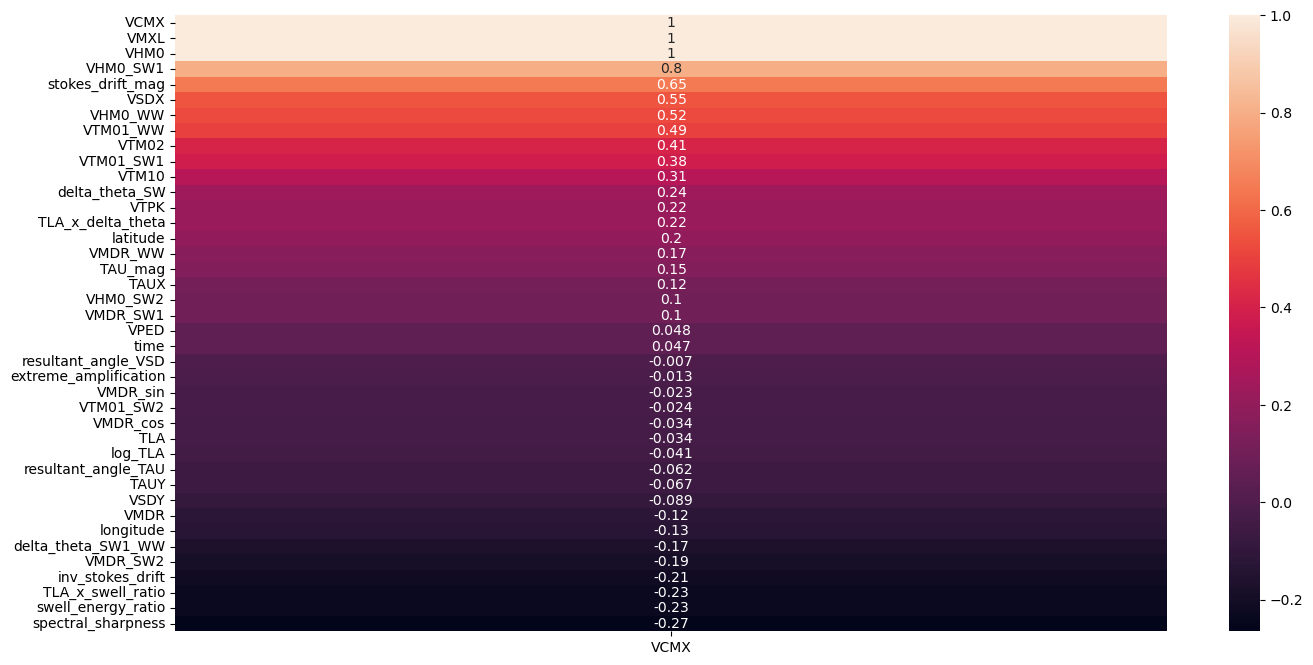

In [16]:
plt.figure(figsize=(16,8))
sns.heatmap(round(corr_matrix[['VCMX']].sort_values('VCMX', ascending=False),3),annot=True)
plt.savefig("correlation_matrix_only.png")

In [ ]:
['VHM0_SW1','strokes_drift_mag','VHM0_WW','VTM01_WW','VTM02','VTM01_SW1','VTM10']

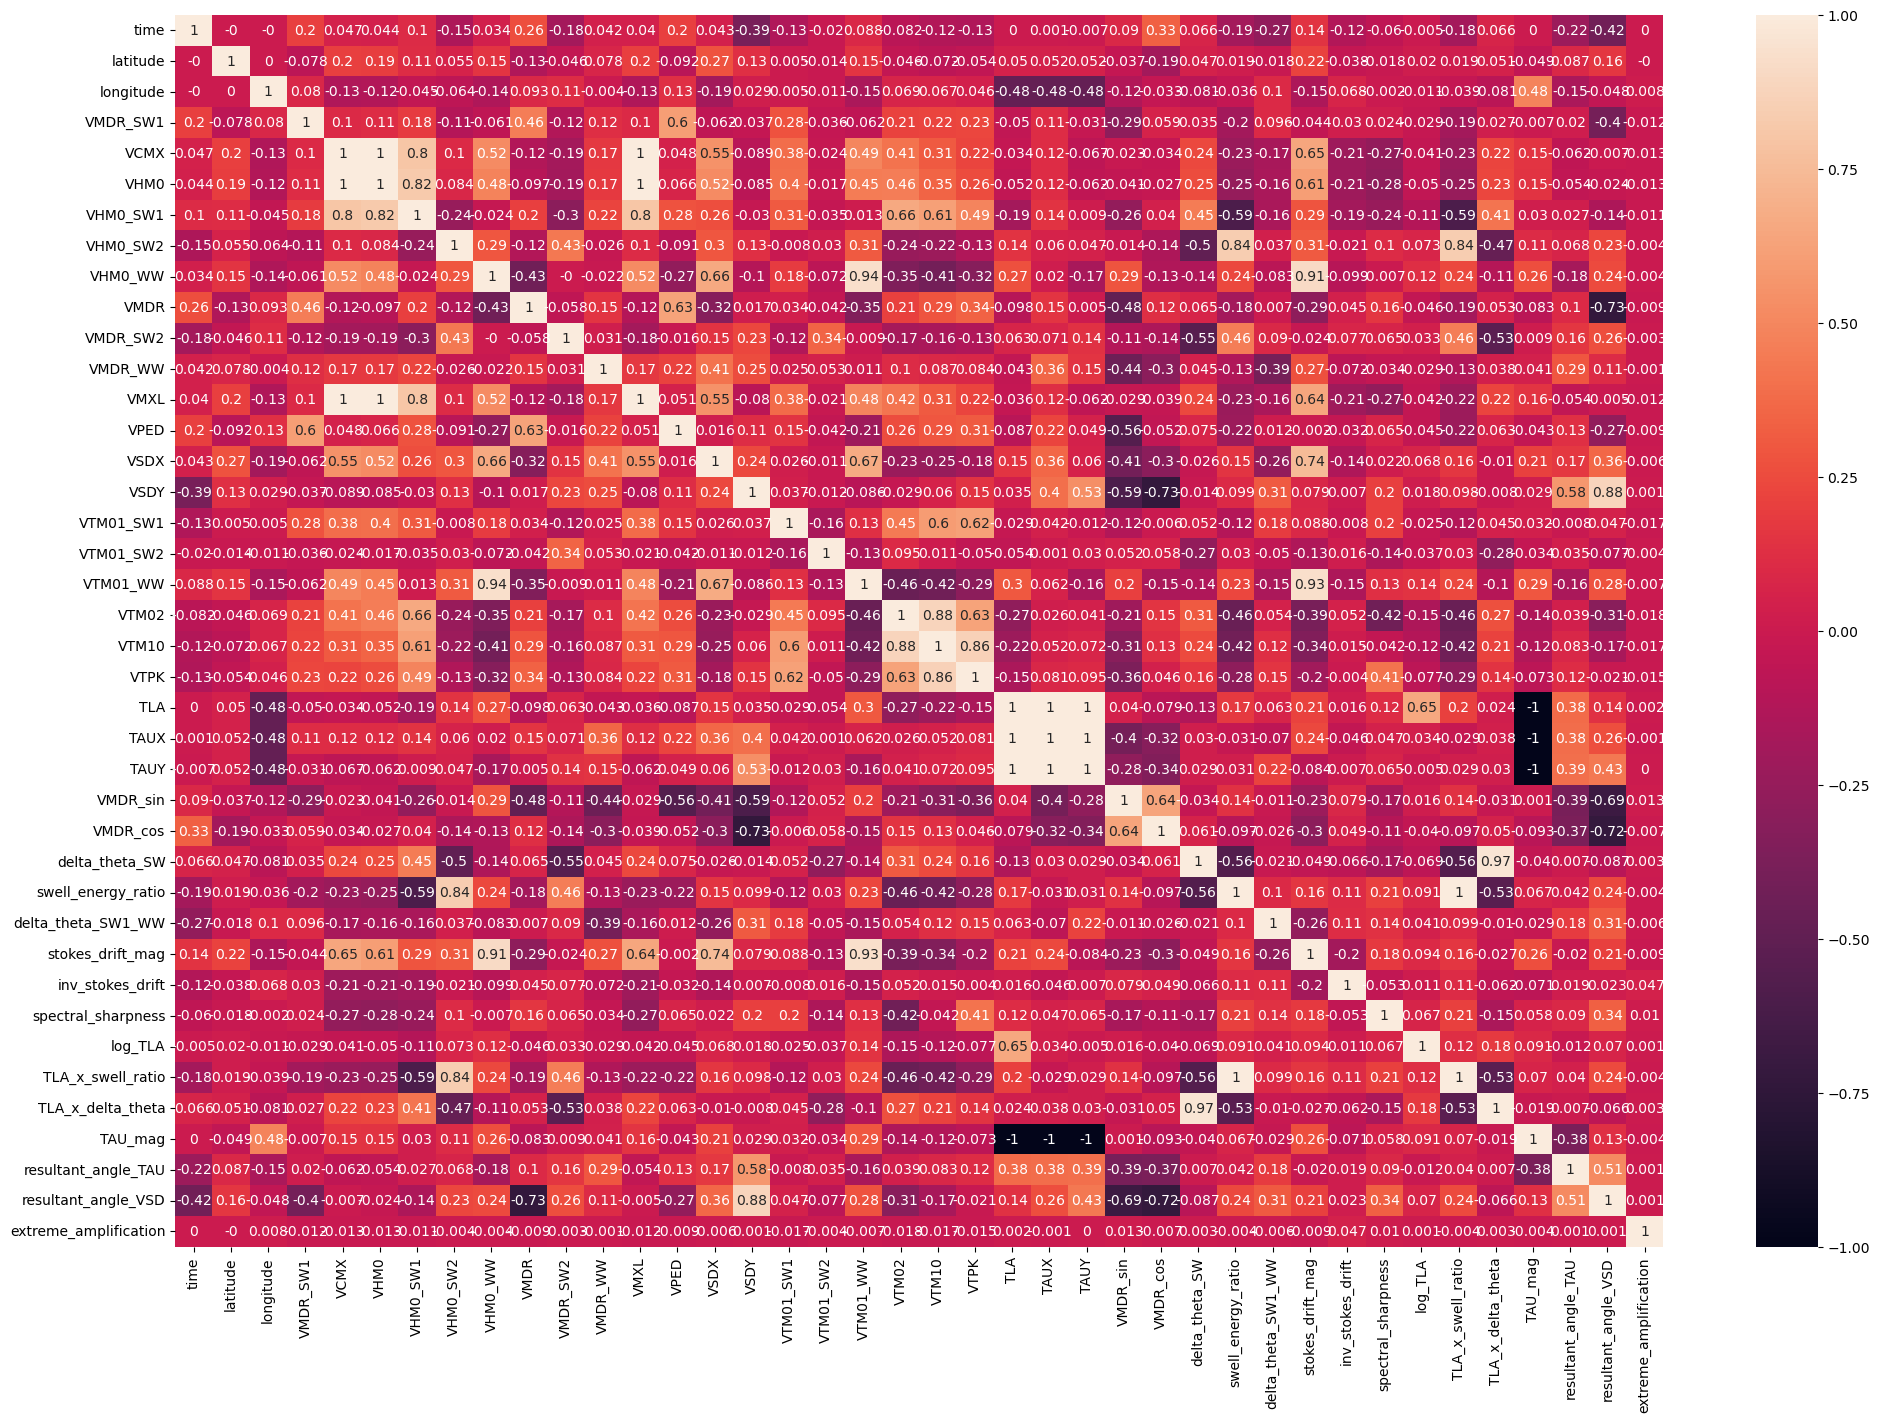

In [ ]:
plt.figure(figsize=(24,16))
sns.heatmap(round(corr_matrix,3),annot=True)
plt.savefig("correlation_matrix.png")

In [ ]:
plt.figure(figsize=(18,10))
sns.heatmap(round(corr_matrix1,3),annot=True)

In [ ]:
selected = ['VSDmag','VTPK','VTM10','VTM02','VTM01_WW','VTM01_SW1','VMXL','VHM0_WW','8']
selected = ['VHM0_SW1','strokes_drift_mag','VHM0_WW','VTM01_WW','VTM02','VTM01_SW1','VTM10']

In [ ]:
corr_matrix1 = df[selected].corr()

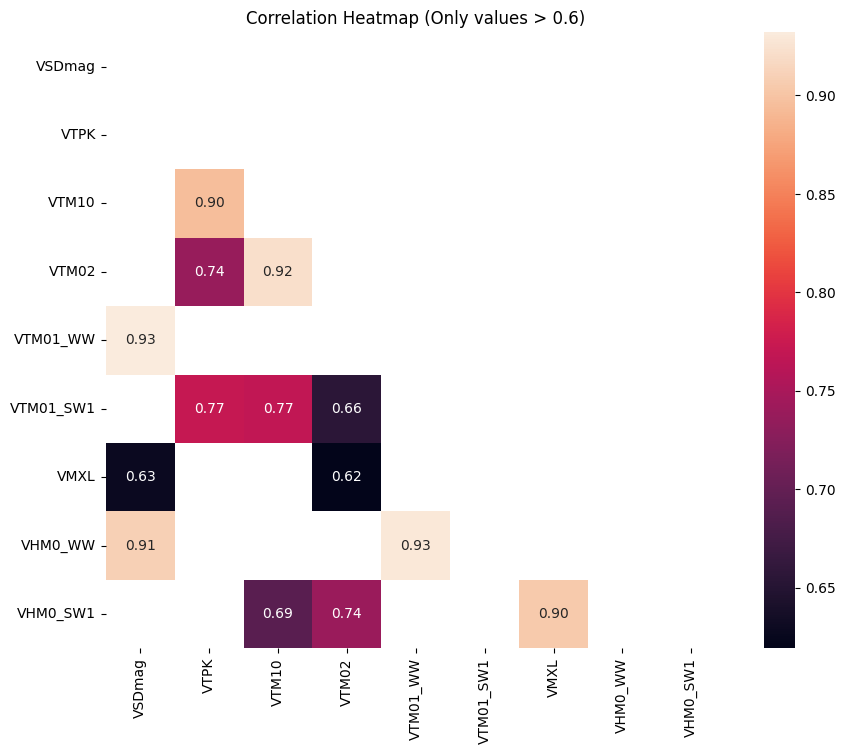

In [ ]:
threshold = 0.6
mask = np.zeros_like(corr_matrix1, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Combine this with a mask for values that do not meet the threshold
mask = mask | (np.abs(corr_matrix) <= threshold)

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix1, mask=mask, annot=True, fmt=".2f")
plt.title(f'Correlation Heatmap (Only values > {threshold})')
plt.show()

In [ ]:
def correlation(corr_matrix, threshold):
    col_corr = set()  
    for i in range(len(corr_matrix.columns)):
        
        for j in range(i):
            # if corr_matrix.columns[j] in selected:
                if abs(corr_matrix.iloc[i, j]) > threshold:  # we are interested in absolute coeff value
                    colname = corr_matrix.columns[i]  # getting the name of column
                    col_corr.add(colname)
    return col_corr
print(correlation(corr_matrix[selected], 0.7))

{'VTM01_SW1', 'VHM0_WW'}


In [ ]:
print(correlation(corr_matrix, 0.7))

set()


<Axes: title={'center': 'Max wave height over time'}, xlabel='time'>

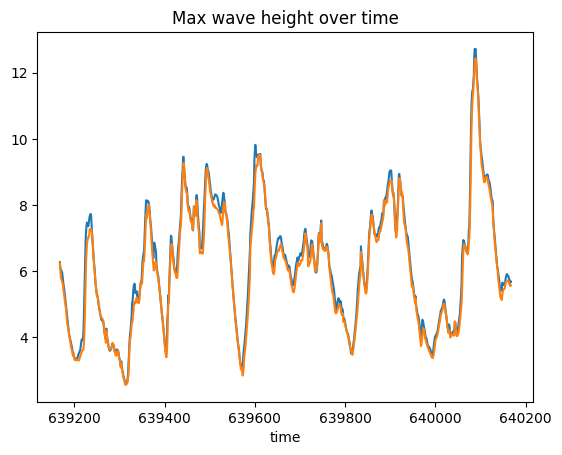

In [ ]:
df.groupby('time')['VCMX'].max().plot(title='Max wave height over time')
df_smooth.groupby('time')['VCMX'].max().plot(title='Max wave height over time')
# df_smooth.groupby('time')['VHM0'].max().plot(title='Mean wave height over time')

In [17]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================
# 1. Load .npy file
# ==============================
data = np.load("new_dAtA/deeplab_embeddings.npy")   # <-- change filename
print("Data shape:", data.shape)

# ==============================
# 2. (OPTIONAL) Feature names
# ==============================
# If you already know the order, put names here.
# Otherwise, auto-generate names.

feature_names = ['VPED','VSDX','VSDY',
    'VTM01_SW1', 'VTM01_SW2', 'VTM01_WW',
    'VTM02', 'VTM10', 'VTPK','VMDR_SW1', 'VCMX', 'VHM0',
    'VHM0_SW1', 'VHM0_SW2', 'VHM0_WW',
    'VMDR', 'VMDR_SW2', 'VMDR_WW', 'VMXL','TLA', 'TAUX', 'TAUY']

if len(feature_names) == data.shape[1]:
    df = pd.DataFrame(data, columns=feature_names)
else:
    df = pd.DataFrame(
        data,
        columns=[f"feat_{i}" for i in range(data.shape[1])]
    )

# ==============================
# 3. Remove constant / invalid columns (IMPORTANT)
# ==============================
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna(axis=1, how="any")

# Drop zero-variance features
df = df.loc[:, df.std() > 0]

print("Usable features:", df.shape[1])


Data shape: (10000, 128)
Usable features: 79


In [18]:
pearson_corr = df.corr(method="pearson")

In [19]:
spearman_corr = df.corr(method="spearman")

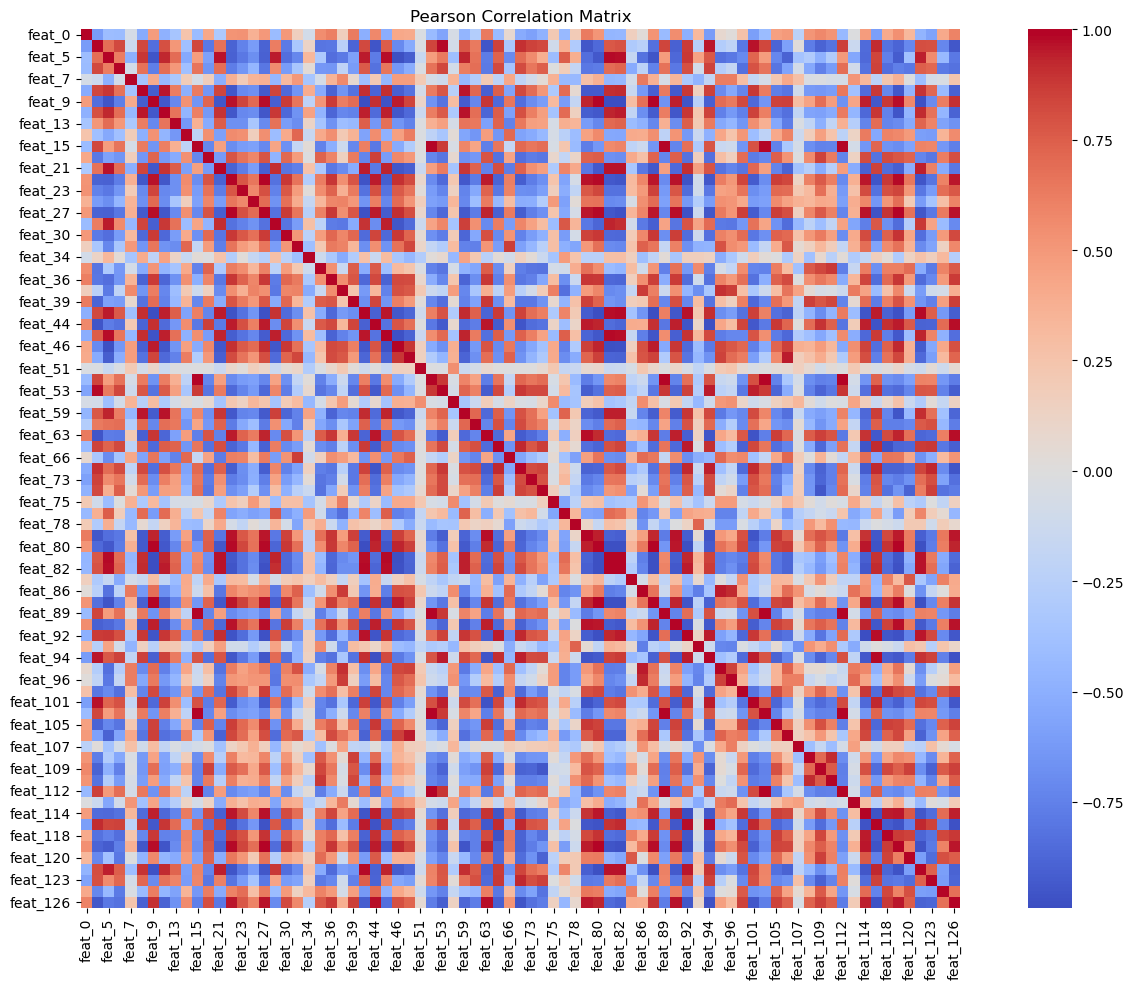

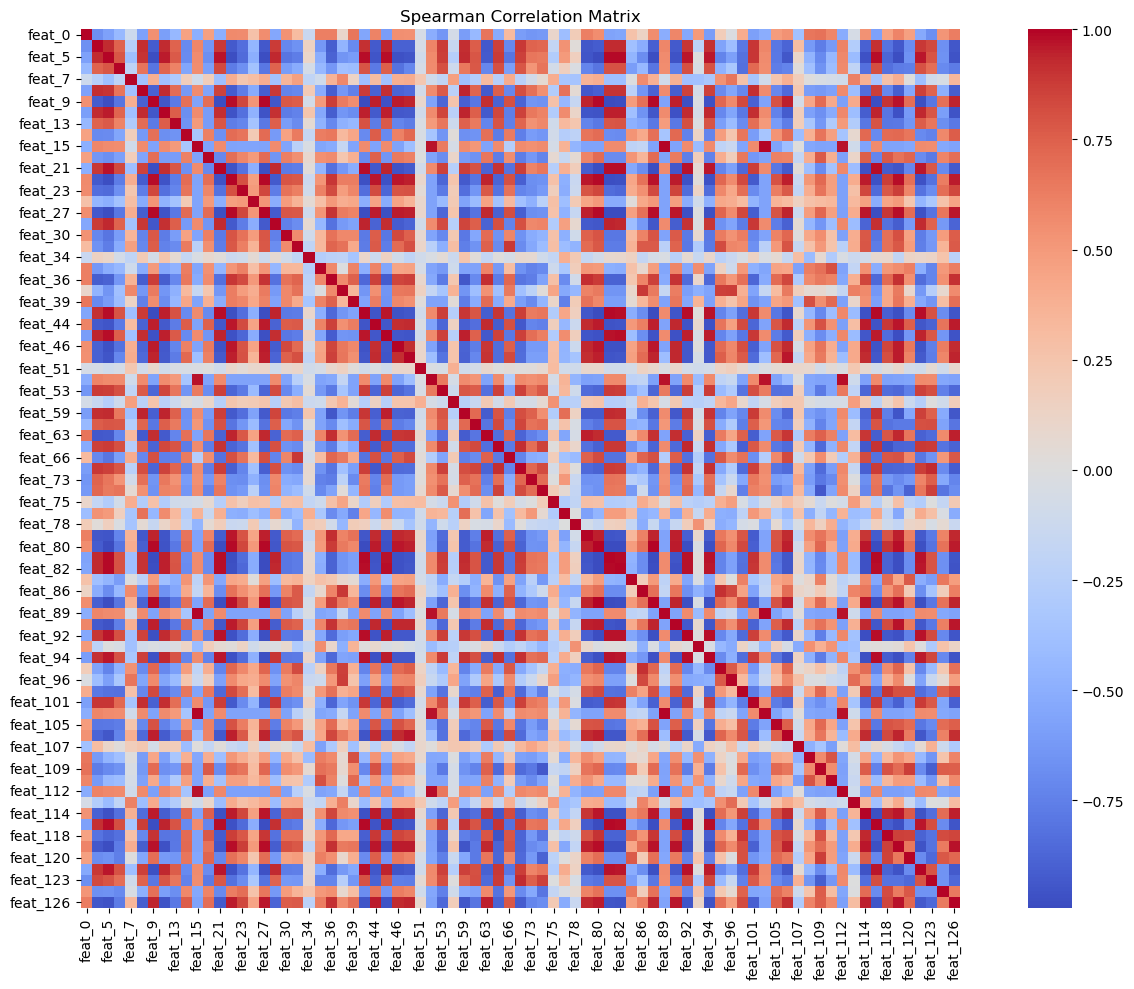

In [20]:
# ==============================
# 6. Plot Pearson correlation
# ==============================
plt.figure(figsize=(14, 10))
sns.heatmap(
    pearson_corr,
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

# ==============================
# 7. Plot Spearman correlation
# ==============================
plt.figure(figsize=(14, 10))
sns.heatmap(
    spearman_corr,
    cmap="coolwarm",
    center=0,
    square=True
)
plt.title("Spearman Correlation Matrix")
plt.tight_layout()
plt.show()

# ==============================
# 8. Save correlation matrices
# ==============================
pearson_corr.to_csv("pearson_corr.csv")
spearman_corr.to_csv("spearman_corr.csv")